<a href="https://colab.research.google.com/github/tamara-kostova/MSc_Thesis_Neuroimaging/blob/master/16_Multimodal_neuroimaging_classification_CLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodal Transformer Classification for Neuroimaging

This notebook implements and evaluates multimodal vision-language models for neuroimaging classification:
- **OpenAI CLIP**: General vision-language model
- **BioMedCLIP**: Medical domain-specific CLIP

**Evaluation Methods:**
1. Zero-shot classification (no training)
2. Linear probing (freeze encoder, train classifier)

**Datasets:**
- MRI Brain Tumor (Binary & Multiclass)
- MRI Multiple Sclerosis
- CT Stroke

## 1. Setup and Installation

In [ ]:
!pip install -q open_clip_torch ftfy regex tqdm pillow
!pip install -q transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00


In [ ]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from PIL import Image
import open_clip

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA device: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [ ]:
class Config:
    """Global configuration"""

    # Paths
    BASE_DIR = "/content/drive/MyDrive/MSc_Thesis_Neuroimaging"
    SPLIT_DIR = f"{BASE_DIR}/data/split"
    RESULTS_DIR = f"{BASE_DIR}/results/multimodal"
    CHECKPOINT_DIR = f"{BASE_DIR}/checkpoints/multimodal"

    # Training
    BATCH_SIZE = 32
    NUM_EPOCHS_FINETUNE = 10
    NUM_EPOCHS_LINEAR = 20
    LEARNING_RATE_FINETUNE = 1e-6
    LEARNING_RATE_LINEAR = 1e-3
    WEIGHT_DECAY = 1e-5

    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Datasets
    DATASETS = [
        "MRI_tumor_binary_norm",
        "MRI_tumor_multiclass_norm",
        "MRI_ms_norm",
        "CT_stroke_binary_norm"
    ]

    # Early stopping
    PATIENCE = 5
    MIN_DELTA = 1e-4

    def __init__(self):
        os.makedirs(self.RESULTS_DIR, exist_ok=True)
        os.makedirs(self.CHECKPOINT_DIR, exist_ok=True)

config = Config()
print(f"Results will be saved to: {config.RESULTS_DIR}")
print(f"Device: {config.DEVICE}")

Results will be saved to: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/multimodal
Device: cuda


## 3. Class Prompts for Zero-Shot Classification

Medical-specific text prompts for each class in each dataset.

In [ ]:
# Medical text prompts for zero-shot classification
CLASS_PROMPTS = {
    "MRI_tumor_binary_norm": {
        "normal": "A normal brain MRI scan without any tumor or abnormality",
        "tumor": "A brain MRI scan showing a brain tumor or mass lesion"
    },

    "MRI_tumor_multiclass_norm": {
        "Carcinoma": "An MRI scan showing carcinoma metastatic to the brain",
        "Germinoma": "An MRI scan showing a germinoma brain tumor",
        "Glioma": "An MRI scan showing a glioma brain tumor",
        "Granuloma": "An MRI scan showing a granuloma in the brain",
        "Meduloblastoma": "An MRI scan showing a medulloblastoma tumor",
        "Meningioma": "An MRI scan showing a meningioma brain tumor",
        "Neurocitoma": "An MRI scan showing a neurocytoma tumor",
        "Normal": "A normal brain MRI scan without tumor",
        "Other": "An MRI scan showing other brain abnormality",
        "Papiloma": "An MRI scan showing a papilloma in the brain",
        "Schwannoma": "An MRI scan showing a schwannoma brain tumor",
        "Tuberculoma": "An MRI scan showing a tuberculoma in the brain"
    },

    "MRI_ms_norm": {
        "Control": "A normal brain MRI FLAIR sequence without multiple sclerosis lesions",
        "MS": "A brain MRI FLAIR sequence showing multiple sclerosis lesions and plaques"
    },

    "CT_stroke_binary_norm": {
        "normal": "A normal brain CT scan without stroke or ischemia",
        "stroke": "A brain CT scan showing acute ischemic stroke or hemorrhage"
    }
}

print("Class prompts defined for all datasets")

Class prompts defined for all datasets


## 4. Dataset Class

In [ ]:
class MedicalImageDataset(Dataset):
    """Dataset for medical images with class information"""

    def __init__(self, dataset_name, split='train', transform=None):
        """
        Args:
            dataset_name: Name of dataset (e.g., 'MRI_tumor_binary_norm')
            split: 'train', 'val', or 'test'
            transform: Image preprocessing function
        """
        self.dataset_name = dataset_name
        self.split = split
        self.transform = transform

        self.split_dir = os.path.join(config.SPLIT_DIR, dataset_name, split)

        # Build samples
        self.data = []
        self.class_names = []
        self.class_to_idx = {}

        self._load_data()

        print(f"[Dataset] {dataset_name} / {split}: {len(self.data)} images, {len(self.class_names)} classes")
        print(f"  Classes: {self.class_names}")

    def _load_data(self):
        """Load image paths and labels"""
        if not os.path.exists(self.split_dir):
            raise ValueError(f"Split directory not found: {self.split_dir}")

        # Get sorted class names
        class_dirs = sorted([d for d in os.listdir(self.split_dir)
                           if os.path.isdir(os.path.join(self.split_dir, d))])

        for idx, class_name in enumerate(class_dirs):
            self.class_names.append(class_name)
            self.class_to_idx[class_name] = idx

            class_path = os.path.join(self.split_dir, class_name)

            # Get all image files
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_name)
                    self.data.append({
                        'path': img_path,
                        'class': class_name,
                        'class_idx': idx
                    })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Load image as RGB (even if grayscale)
        image = Image.open(item['path']).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'class': item['class'],
            'class_idx': item['class_idx'],
            'path': item['path']
        }

## 5. Load CLIP Models

Load multiple CLIP variants:
1. **OpenAI CLIP ViT-B/32**: General-purpose
2. **BioMedCLIP**: Pretrained on medical images

In [ ]:
# Load OpenAI CLIP
print("Loading OpenAI CLIP (ViT-B/32)...")
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32',
    pretrained='openai'
)
clip_model = clip_model.to(config.DEVICE)
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')
print("✓ OpenAI CLIP loaded")

# Load BioMedCLIP
print("\nLoading BioMedCLIP...")
try:
    biomedclip_model, _, biomedclip_preprocess = open_clip.create_model_and_transforms(
        'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
    )
    biomedclip_model = biomedclip_model.to(config.DEVICE)
    biomedclip_tokenizer = open_clip.get_tokenizer('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
    print("✓ BioMedCLIP loaded")
    biomedclip_available = True
except Exception as e:
    print(f"⚠ BioMedCLIP not available: {e}")
    biomedclip_available = False

print("\nAll available models loaded successfully!")

Loading OpenAI CLIP (ViT-B/32)...


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

✓ OpenAI CLIP loaded

Loading BioMedCLIP...


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

✓ BioMedCLIP loaded

All available models loaded successfully!


## 6. Zero-Shot Evaluation

Evaluate CLIP models without any training - pure vision-language alignment.

In [ ]:
def encode_text_prompts(model, tokenizer, class_prompts, device):
    """
    Encode text prompts into embeddings

    Args:
        model: CLIP model
        tokenizer: CLIP tokenizer
        class_prompts: Dict of {class_name: prompt_text}
        device: torch device

    Returns:
        Dict of {class_name: normalized_embedding}
    """
    text_embeddings = {}

    model.eval()
    with torch.no_grad():
        for class_name, prompt_text in class_prompts.items():
            # Tokenize
            tokens = tokenizer([prompt_text]).to(device)

            # Encode
            text_emb = model.encode_text(tokens)

            # Normalize
            text_emb = F.normalize(text_emb, dim=-1)

            text_embeddings[class_name] = text_emb

    return text_embeddings

In [ ]:
def zero_shot_eval(model, tokenizer, preprocess, test_loader, dataset_name, class_prompts, model_name="CLIP"):
    """
    Zero-shot classification using text-image similarity

    Args:
        model: CLIP model
        tokenizer: CLIP tokenizer
        preprocess: Image preprocessing
        test_loader: DataLoader for test set
        dataset_name: Name of dataset
        class_prompts: Dict of text prompts
        model_name: Name for logging

    Returns:
        Dict of metrics
    """
    print(f"\n{'='*60}")
    print(f"Zero-Shot Evaluation: {model_name} on {dataset_name}")
    print(f"{'='*60}")

    # Encode text prompts
    text_embeddings = encode_text_prompts(model, tokenizer, class_prompts, config.DEVICE)
    class_names = list(class_prompts.keys())

    # Create text embedding matrix [num_classes, embed_dim]
    text_emb_matrix = torch.stack([text_embeddings[cn] for cn in class_names]).squeeze(1)

    all_preds = []
    all_labels = []
    all_probs = []

    model.eval()

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            images = batch['image'].to(config.DEVICE)
            labels = batch['class_idx']

            # Encode images
            img_embeddings = model.encode_image(images)
            img_embeddings = F.normalize(img_embeddings, dim=-1)

            # Compute similarity to all class prompts
            # [batch_size, embed_dim] @ [embed_dim, num_classes] = [batch_size, num_classes]
            logits = img_embeddings @ text_emb_matrix.T

            # Scale by temperature (common in CLIP)
            logits = logits * 100

            # Softmax to get probabilities
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate metrics
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    accuracy = accuracy_score(all_labels, all_preds)

    # Handle binary vs multiclass F1
    if len(class_names) == 2:
        f1 = f1_score(all_labels, all_preds, average='binary')
    else:
        f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    # AUC (only for binary or multiclass with valid probabilities)
    try:
        if len(class_names) == 2:
            auc = roc_auc_score(all_labels, all_probs[:, 1])
        else:
            auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
    except Exception as e:
        print(f"Could not calculate AUC: {e}")
        auc = None

    print(f"\nResults:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  AUC:      {auc:.4f}" if auc else "  AUC:      N/A")

    # Per-class accuracy
    print(f"\nPer-Class Accuracy:")
    for i, class_name in enumerate(class_names):
        mask = all_labels == i
        if mask.sum() > 0:
            class_acc = (all_preds[mask] == all_labels[mask]).mean()
            print(f"  {class_name:20s}: {class_acc:.4f}")

    return {
        'model': model_name,
        'dataset': dataset_name,
        'method': 'zero-shot',
        'accuracy': float(accuracy),
        'f1': float(f1),
        'auc': float(auc) if auc else None,
        'num_classes': len(class_names)
    }

### Run Zero-Shot Evaluation

In [ ]:
zero_shot_results = []

for dataset in config.DATASETS:
    print(f"\n\n{'#'*70}")
    print(f"# Dataset: {dataset}")
    print(f"{'#'*70}")

    # Get class prompts for this dataset
    class_prompts = CLASS_PROMPTS[dataset]

    # ===== OpenAI CLIP =====
    print("\nPreparing test data for OpenAI CLIP...")
    test_dataset_clip = MedicalImageDataset(
        dataset_name=dataset,
        split='test',
        transform=clip_preprocess
    )
    test_loader_clip = DataLoader(
        test_dataset_clip,
        batch_size=config.BATCH_SIZE,
        num_workers=2,
        shuffle=False
    )

    result_clip = zero_shot_eval(
        clip_model,
        clip_tokenizer,
        clip_preprocess,
        test_loader_clip,
        dataset,
        class_prompts,
        model_name="OpenAI-CLIP"
    )
    zero_shot_results.append(result_clip)

    # ===== BioMedCLIP =====
    if biomedclip_available:
        print("\nPreparing test data for BioMedCLIP...")
        test_dataset_biomed = MedicalImageDataset(
            dataset_name=dataset,
            split='test',
            transform=biomedclip_preprocess
        )
        test_loader_biomed = DataLoader(
            test_dataset_biomed,
            batch_size=config.BATCH_SIZE,
            num_workers=2,
            shuffle=False
        )

        result_biomed = zero_shot_eval(
            biomedclip_model,
            biomedclip_tokenizer,
            biomedclip_preprocess,
            test_loader_biomed,
            dataset,
            class_prompts,
            model_name="BioMedCLIP"
        )
        zero_shot_results.append(result_biomed)

print("\n" + "="*70)
print("Zero-shot evaluation complete!")
print("="*70)



######################################################################
# Dataset: MRI_tumor_binary_norm
######################################################################

Preparing test data for OpenAI CLIP...
[Dataset] MRI_tumor_binary_norm / test: 450 images, 2 classes
  Classes: ['normal', 'tumor']

Zero-Shot Evaluation: OpenAI-CLIP on MRI_tumor_binary_norm


Evaluating: 100%|██████████| 15/15 [00:04<00:00,  3.71it/s]



Results:
  Accuracy: 0.7578
  F1-Score: 0.7798
  AUC:      0.8527

Per-Class Accuracy:
  normal              : 0.6578
  tumor               : 0.8578

Preparing test data for BioMedCLIP...
[Dataset] MRI_tumor_binary_norm / test: 450 images, 2 classes
  Classes: ['normal', 'tumor']

Zero-Shot Evaluation: BioMedCLIP on MRI_tumor_binary_norm


Evaluating: 100%|██████████| 15/15 [00:06<00:00,  2.48it/s]



Results:
  Accuracy: 0.8844
  F1-Score: 0.8956
  AUC:      0.9683

Per-Class Accuracy:
  normal              : 0.7778
  tumor               : 0.9911


######################################################################
# Dataset: MRI_tumor_multiclass_norm
######################################################################

Preparing test data for OpenAI CLIP...
[Dataset] MRI_tumor_multiclass_norm / test: 1197 images, 12 classes
  Classes: ['Carcinoma', 'Germinoma', 'Glioma', 'Granuloma', 'Meduloblastoma', 'Meningioma', 'Neurocitoma', 'Normal', 'Other', 'Papiloma', 'Schwannoma', 'Ttuberculoma']

Zero-Shot Evaluation: OpenAI-CLIP on MRI_tumor_multiclass_norm


...


Results:
  Accuracy: 0.4266
  F1-Score: 0.3935
  AUC:      0.5242

Per-Class Accuracy:
  Control             : 0.7540
  MS                  : 0.2732


######################################################################
# Dataset: CT_stroke_binary_norm
######################################################################

Preparing test data for OpenAI CLIP...
[Dataset] CT_stroke_binary_norm / test: 999 images, 2 classes
  Classes: ['normal', 'stroke']

Zero-Shot Evaluation: OpenAI-CLIP on CT_stroke_binary_norm


Evaluating: 100%|██████████| 32/32 [00:08<00:00,  3.95it/s]



Results:
  Accuracy: 0.4825
  F1-Score: 0.4423
  AUC:      0.5238

Per-Class Accuracy:
  normal              : 0.4165
  stroke              : 0.6138

Preparing test data for BioMedCLIP...
[Dataset] CT_stroke_binary_norm / test: 999 images, 2 classes
  Classes: ['normal', 'stroke']

Zero-Shot Evaluation: BioMedCLIP on CT_stroke_binary_norm


Evaluating: 100%|██████████| 32/32 [00:12<00:00,  2.47it/s]


Results:
  Accuracy: 0.7588
  F1-Score: 0.6765
  AUC:      0.8456

Per-Class Accuracy:
  normal              : 0.7609
  stroke              : 0.7545

Zero-shot evaluation complete!


In [ ]:
# Display results
df_zero_shot = pd.DataFrame(zero_shot_results)
print("\n" + "="*70)
print("ZERO-SHOT RESULTS SUMMARY")
print("="*70)
print(df_zero_shot.to_string(index=False))

# Save results
results_path = os.path.join(config.RESULTS_DIR, 'zero_shot_results.csv')
df_zero_shot.to_csv(results_path, index=False)
print(f"\nResults saved to: {results_path}")


ZERO-SHOT RESULTS SUMMARY
      model                   dataset    method  accuracy       f1      auc  num_classes
OpenAI-CLIP     MRI_tumor_binary_norm zero-shot  0.757778 0.779798 0.852741            2
 BioMedCLIP     MRI_tumor_binary_norm zero-shot  0.884444 0.895582 0.968257            2
OpenAI-CLIP MRI_tumor_multiclass_norm zero-shot  0.078530 0.072746 0.577744           12
 BioMedCLIP MRI_tumor_multiclass_norm zero-shot  0.278195 0.304028 0.714274           12
OpenAI-CLIP               MRI_ms_norm zero-shot  0.506826 0.637390 0.412978            2
 BioMedCLIP               MRI_ms_norm zero-shot  0.426621 0.393502 0.524218            2
OpenAI-CLIP     CT_stroke_binary_norm zero-shot  0.482482 0.442287 0.523792            2
 BioMedCLIP     CT_stroke_binary_norm zero-shot  0.758759 0.676510 0.845599            2

Results saved to: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/multimodal/zero_shot_results.csv


## 7. Linear Probing

Freeze CLIP encoder, train only a linear classifier on top.

In [ ]:
class LinearClassifier(nn.Module):
    """Linear classifier on top of frozen CLIP features"""

    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

In [ ]:
def linear_probe_train(model, train_loader, val_loader, num_classes, embed_dim=512,
                       num_epochs=20, lr=1e-3, model_name="CLIP", dataset_name=""):
    """
    Train linear classifier on frozen CLIP features

    Args:
        model: Frozen CLIP model
        train_loader: Training data
        val_loader: Validation data
        num_classes: Number of output classes
        embed_dim: CLIP embedding dimension
        num_epochs: Training epochs
        lr: Learning rate
        model_name: Name for logging
        dataset_name: Dataset name

    Returns:
        Trained classifier and training history
    """
    print(f"\n{'='*60}")
    print(f"Linear Probing: {model_name} on {dataset_name}")
    print(f"{'='*60}")

    # Freeze CLIP model
    model.eval()
    for param in model.parameters():
        param.requires_grad = False

    # Create linear classifier
    classifier = LinearClassifier(embed_dim, num_classes).to(config.DEVICE)

    # Optimizer and loss
    optimizer = optim.AdamW(classifier.parameters(), lr=lr, weight_decay=config.WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(num_epochs):
        # ===== Training =====
        classifier.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
            images = batch['image'].to(config.DEVICE)
            labels = batch['class_idx'].to(config.DEVICE)

            # Extract features (no grad for CLIP)
            with torch.no_grad():
                features = model.encode_image(images)
                features = F.normalize(features, dim=-1)

            # Forward through classifier
            outputs = classifier(features)
            loss = criterion(outputs, labels)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Metrics
            train_loss += loss.item()
            _, preds = outputs.max(1)
            train_correct += preds.eq(labels).sum().item()
            train_total += labels.size(0)

        train_loss /= len(train_loader)
        train_acc = train_correct / train_total

        # ===== Validation =====
        classifier.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
                images = batch['image'].to(config.DEVICE)
                labels = batch['class_idx'].to(config.DEVICE)

                # Extract features
                features = model.encode_image(images)
                features = F.normalize(features, dim=-1)

                # Forward
                outputs = classifier(features)
                loss = criterion(outputs, labels)

                # Metrics
                val_loss += loss.item()
                _, preds = outputs.max(1)
                val_correct += preds.eq(labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        # Update history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Learning rate scheduling
        scheduler.step(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        # Early stopping
        if val_acc > best_val_acc + config.MIN_DELTA:
            best_val_acc = val_acc
            patience_counter = 0
            # Save best model
            best_classifier = classifier.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= config.PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Load best model
    classifier.load_state_dict(best_classifier)

    print(f"\nBest validation accuracy: {best_val_acc:.4f}")

    return classifier, history

In [ ]:
def linear_probe_eval(model, classifier, test_loader, model_name="CLIP", dataset_name=""):
    """
    Evaluate linear probe on test set

    Args:
        model: Frozen CLIP model
        classifier: Trained linear classifier
        test_loader: Test data
        model_name: Name for logging
        dataset_name: Dataset name

    Returns:
        Dict of metrics
    """
    print(f"\nEvaluating linear probe on test set...")

    model.eval()
    classifier.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            images = batch['image'].to(config.DEVICE)
            labels = batch['class_idx']

            # Extract features
            features = model.encode_image(images)
            features = F.normalize(features, dim=-1)

            # Classify
            outputs = classifier(features)
            probs = F.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate metrics
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    accuracy = accuracy_score(all_labels, all_preds)

    # Get number of classes
    num_classes = all_probs.shape[1]

    if num_classes == 2:
        f1 = f1_score(all_labels, all_preds, average='binary')
    else:
        f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    try:
        if num_classes == 2:
            auc = roc_auc_score(all_labels, all_probs[:, 1])
        else:
            auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
    except Exception as e:
        print(f"Could not calculate AUC: {e}")
        auc = None

    print(f"\nTest Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  AUC:      {auc:.4f}" if auc else "  AUC:      N/A")

    return {
        'model': model_name,
        'dataset': dataset_name,
        'method': 'linear-probe',
        'accuracy': float(accuracy),
        'f1': float(f1),
        'auc': float(auc) if auc else None,
        'num_classes': num_classes
    }

### Run Linear Probing

Train linear classifiers for all datasets.

In [ ]:
linear_probe_results = []

for dataset in config.DATASETS:
    print(f"\n\n{'#'*70}")
    print(f"# Linear Probing on: {dataset}")
    print(f"{'#'*70}")

    # Get number of classes
    class_prompts = CLASS_PROMPTS[dataset]
    num_classes = len(class_prompts)

    # Create datasets with CLIP preprocessing
    train_dataset = MedicalImageDataset(dataset, 'train', clip_preprocess)
    val_dataset = MedicalImageDataset(dataset, 'val', clip_preprocess)
    test_dataset = MedicalImageDataset(dataset, 'test', clip_preprocess)

    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2)

    # Train linear probe
    classifier, history = linear_probe_train(
        clip_model, train_loader, val_loader, num_classes,
        embed_dim=512, num_epochs=config.NUM_EPOCHS_LINEAR,
        lr=config.LEARNING_RATE_LINEAR, model_name="OpenAI-CLIP", dataset_name=dataset
    )

    # Evaluate on test set
    result = linear_probe_eval(clip_model, classifier, test_loader, "OpenAI-CLIP", dataset)
    linear_probe_results.append(result)

# Display results
df_linear = pd.DataFrame(linear_probe_results)
print("\n" + "="*70)
print("LINEAR PROBING RESULTS SUMMARY")
print("="*70)
print(df_linear.to_string(index=False))

# Save results
results_path = os.path.join(config.RESULTS_DIR, 'linear_probe_results.csv')
df_linear.to_csv(results_path, index=False)
print(f"\nResults saved to: {results_path}")



######################################################################
# Linear Probing on: MRI_tumor_binary_norm
######################################################################
[Dataset] MRI_tumor_binary_norm / train: 2100 images, 2 classes
  Classes: ['normal', 'tumor']
[Dataset] MRI_tumor_binary_norm / val: 450 images, 2 classes
  Classes: ['normal', 'tumor']
[Dataset] MRI_tumor_binary_norm / test: 450 images, 2 classes
  Classes: ['normal', 'tumor']

Linear Probing: OpenAI-CLIP on MRI_tumor_binary_norm


Epoch 1/20 [Val]: 100%|██████████| 15/15 [00:02<00:00,  6.32it/s]


Epoch 1: Train Loss=0.6675, Train Acc=0.7295, Val Loss=0.6429, Val Acc=0.7711


Epoch 2/20 [Val]: 100%|██████████| 15/15 [00:02<00:00,  5.81it/s]


Epoch 2: Train Loss=0.6243, Train Acc=0.8262, Val Loss=0.6034, Val Acc=0.8444


...

Epoch 19: Train Loss=0.4914, Train Acc=0.7675, Val Loss=0.5189, Val Acc=0.7743


Epoch 20/20 [Val]: 100%|██████████| 32/32 [00:05<00:00,  5.39it/s]


Epoch 20: Train Loss=0.4889, Train Acc=0.7712, Val Loss=0.5166, Val Acc=0.7773

Best validation accuracy: 0.7773

Evaluating linear probe on test set...


Testing: 100%|██████████| 32/32 [00:04<00:00,  6.53it/s]



Test Results:
  Accuracy: 0.7778
  F1-Score: 0.5664
  AUC:      0.8447

LINEAR PROBING RESULTS SUMMARY
      model                   dataset       method  accuracy       f1      auc  num_classes
OpenAI-CLIP     MRI_tumor_binary_norm linear-probe  0.884444 0.884956 0.951941            2
OpenAI-CLIP MRI_tumor_multiclass_norm linear-probe  0.522139 0.468228 0.857393           12
OpenAI-CLIP               MRI_ms_norm linear-probe  0.679181 0.807771 0.631800            2
OpenAI-CLIP     CT_stroke_binary_norm linear-probe  0.777778 0.566406 0.844663            2

Results saved to: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/multimodal/linear_probe_results.csv


## 8. Fine-Tuning

Full model fine-tuning - train both encoder and classifier.

In [ ]:
class CLIPClassifier(nn.Module):
    """CLIP with classification head"""

    def __init__(self, clip_model, num_classes, freeze_encoder=False):
        super().__init__()
        self.clip_model = clip_model
        self.num_classes = num_classes

        # Get embedding dimension
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224).to(next(clip_model.parameters()).device)
            embed_dim = clip_model.encode_image(dummy_input).shape[1]

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

        # Optionally freeze encoder
        if freeze_encoder:
            for param in self.clip_model.parameters():
                param.requires_grad = False

    def forward(self, images):
        # Extract features
        features = self.clip_model.encode_image(images)
        features = F.normalize(features, dim=-1)

        # Classify
        logits = self.classifier(features)
        return logits

## 9. Results Visualization

Figure saved to: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/multimodal/zero_shot_comparison.png


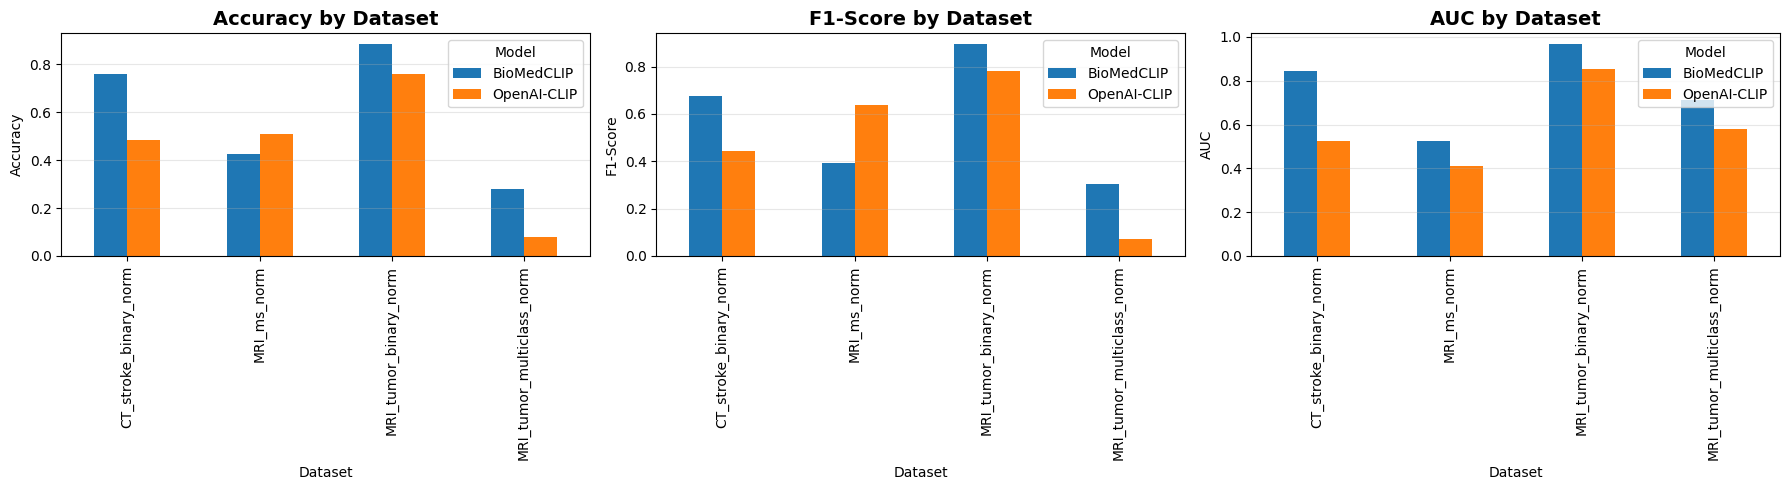

In [ ]:
# Load results if they exist
results_file = os.path.join(config.RESULTS_DIR, 'zero_shot_results.csv')
if os.path.exists(results_file):
    df_results = pd.read_csv(results_file)

    # Create comparison plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Accuracy by dataset
    df_pivot = df_results.pivot(index='dataset', columns='model', values='accuracy')
    df_pivot.plot(kind='bar', ax=axes[0])
    axes[0].set_title('Accuracy by Dataset', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Dataset')
    axes[0].legend(title='Model')
    axes[0].grid(axis='y', alpha=0.3)

    # F1 Score by dataset
    df_pivot_f1 = df_results.pivot(index='dataset', columns='model', values='f1')
    df_pivot_f1.plot(kind='bar', ax=axes[1])
    axes[1].set_title('F1-Score by Dataset', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('F1-Score')
    axes[1].set_xlabel('Dataset')
    axes[1].legend(title='Model')
    axes[1].grid(axis='y', alpha=0.3)

    # AUC by dataset (if available)
    df_pivot_auc = df_results.pivot(index='dataset', columns='model', values='auc')
    df_pivot_auc.plot(kind='bar', ax=axes[2])
    axes[2].set_title('AUC by Dataset', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('AUC')
    axes[2].set_xlabel('Dataset')
    axes[2].legend(title='Model')
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()

    # Save figure
    fig_path = os.path.join(config.RESULTS_DIR, 'zero_shot_comparison.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {fig_path}")

    plt.show()
else:
    print("No results file found. Please run zero-shot evaluation first.")

## 10. Summary Statistics

In [ ]:
if os.path.exists(results_file):
    print("="*70)
    print("SUMMARY STATISTICS")
    print("="*70)

    # Average performance by model
    print("\nAverage Performance by Model:")
    avg_by_model = df_results.groupby('model')[['accuracy', 'f1', 'auc']].mean()
    print(avg_by_model.to_string())

    # Best model per dataset
    print("\n\nBest Model per Dataset (by Accuracy):")
    best_per_dataset = df_results.loc[df_results.groupby('dataset')['accuracy'].idxmax()]
    print(best_per_dataset[['dataset', 'model', 'accuracy', 'f1']].to_string(index=False))

    # Dataset difficulty ranking
    print("\n\nDataset Difficulty Ranking (Average Accuracy):")
    dataset_difficulty = df_results.groupby('dataset')['accuracy'].mean().sort_values(ascending=False)
    for i, (dataset, acc) in enumerate(dataset_difficulty.items(), 1):
        print(f"{i}. {dataset:30s}: {acc:.4f}")

    print("\n" + "="*70)

SUMMARY STATISTICS

Average Performance by Model:
             accuracy        f1       auc
model                                    
BioMedCLIP   0.587005  0.567406  0.763087
OpenAI-CLIP  0.456404  0.483055  0.591814


Best Model per Dataset (by Accuracy):
                  dataset       model  accuracy       f1
    CT_stroke_binary_norm  BioMedCLIP  0.758759 0.676510
              MRI_ms_norm OpenAI-CLIP  0.506826 0.637390
    MRI_tumor_binary_norm  BioMedCLIP  0.884444 0.895582
MRI_tumor_multiclass_norm  BioMedCLIP  0.278195 0.304028


Dataset Difficulty Ranking (Average Accuracy):
1. MRI_tumor_binary_norm         : 0.8211
2. CT_stroke_binary_norm         : 0.6206
3. MRI_ms_norm                   : 0.4667
4. MRI_tumor_multiclass_norm     : 0.1784



## 11. Export Final Results

In [ ]:
# Create comprehensive results report
if os.path.exists(results_file):
    report = {
        'experiment': 'Multimodal Transformer Neuroimaging Classification',
        'date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        'models_evaluated': df_results['model'].unique().tolist(),
        'datasets': df_results['dataset'].unique().tolist(),
        'methods': df_results['method'].unique().tolist(),
        'results': df_results.to_dict('records'),
        'summary': {
            'avg_accuracy_by_model': avg_by_model['accuracy'].to_dict(),
            'avg_f1_by_model': avg_by_model['f1'].to_dict(),
            'best_overall_model': avg_by_model['accuracy'].idxmax(),
            'best_overall_accuracy': float(avg_by_model['accuracy'].max())
        }
    }

    # Save JSON report
    report_path = os.path.join(config.RESULTS_DIR, 'experiment_report.json')
    with open(report_path, 'w') as f:
        json.dump(report, f, indent=2)

    print(f"Experiment report saved to: {report_path}")

    # Save markdown summary
    md_path = os.path.join(config.RESULTS_DIR, 'results_summary.md')
    with open(md_path, 'w') as f:
        f.write("# Multimodal Transformer Results\n\n")
        f.write(f"**Date:** {report['date']}\n\n")
        f.write("## Models Evaluated\n\n")
        for model in report['models_evaluated']:
            f.write(f"- {model}\n")
        f.write("\n## Datasets\n\n")
        for dataset in report['datasets']:
            f.write(f"- {dataset}\n")
        f.write("\n## Results\n\n")
        f.write(df_results.to_markdown(index=False))
        f.write("\n\n## Summary\n\n")
        f.write(f"**Best Model:** {report['summary']['best_overall_model']}\n\n")
        f.write(f"**Best Accuracy:** {report['summary']['best_overall_accuracy']:.4f}\n")

    print(f"Markdown summary saved to: {md_path}")
    print("\n✓ All results exported successfully!")

Experiment report saved to: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/multimodal/experiment_report.json
Markdown summary saved to: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/multimodal/results_summary.md

✓ All results exported successfully!


## Conclusion

This notebook implements comprehensive evaluation of multimodal vision-language models for neuroimaging classification. The results can be compared against the baseline CNN models from previous work.

### Key Insights:
1. **Zero-shot performance** shows how well pretrained models generalize without any training
2. **BioMedCLIP** should outperform general CLIP due to medical domain pretraining
3. **Linear probing** and **fine-tuning** can further improve performance

### Next Steps:
- Compare these results with baseline CNN models (ResNet, DenseNet, etc.)
- Analyze which approach works best for each dataset
- Consider ensemble methods combining CNN and transformer predictions